In [1]:
from dataclasses import dataclass
from fractions import Fraction
from functools import reduce
from math import lcm

import numpy as np
import matplotlib.pyplot as plt
import time

# import spcm
# from spcm import units


plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

In [2]:
@dataclass(frozen=True)
class AWGConfig:
    card_resource: str = "/dev/spcm0"
    sample_rate_mhz: int = 625
    segment_alignment_samples: int = 32
    sequence_memory_slots: int = 4
    max_loop_samples: int = 10_000_000

    empty_tone_ramp_us: float = 2.0
    movement_us_per_site: float = 5.0
    minimum_movement_us: float = 2.0
    phase_settle_us: float = 10.0
    phi1_rad: float = 0.0

    dac_headroom: float = 0.85
    dac_max_code: int = 32767
    min_output_range_mv: float = 80.0
    max_output_range_mv: float = 2500.0


@dataclass(frozen=True)
class AWGChannelConfig:
    index: int
    single_tone_amplitude_mv: float
    load_ohm: int
    max_average_output_power_dbm: float = 3


class signal_generator:
    # 1. Shared functions
    def __init__(self, config, channel_configs):
        self.config = config
        self.channel_configs = tuple(sorted(channel_configs, key=lambda ch: ch.index))
        self.length = len(self.channel_configs) # the number of the active channels

    def get_calibrated_relative_amplitude(self, frequency):
        return np.ones_like(frequency)
    
    def generate_waveform(self,frequencies_mhz, phase0):
        """
        generate the waveform for both static stage and dynamic stage
    
        the frequencies_mhz should be a 2D array, the first index is the tone and the second index is the sample
    
        relative amplitudes calibrated
    
        phase0 is a 1d array that contains the initial phase of the waveform
    
        sample_rate_mhz is the card sample rate
        """
        
        if len(frequencies_mhz) !=len(phase0):
            raise ValueError("The number of phase should match the number of the tones")
            
        increments = 2*np.pi*frequencies_mhz/self.config.sample_rate_mhz
        phase = phase0[:, None] + np.cumsum(np.column_stack([np.zeros(len(phase0)), increments[:, :-1]]), axis=1)
        relative_amplitudes = self.get_calibrated_relative_amplitude(frequencies_mhz)
        waveform = np.sum(relative_amplitudes * np.cos(phase), axis=0)
        phase_next = phase0 + np.sum(increments, axis=1)
        return waveform, phase, phase_next

    def get_output_range_mv(self,waveform, single_tone_amplitude_mv ):
        """
        calculate the channel output range in mV based on the waveform and single tone amplitude
        """
        
        worst_case_peak_mv = np.max(np.abs(waveform)) * single_tone_amplitude_mv
        output_range_mv = np.ceil(worst_case_peak_mv/self.config.dac_headroom)
        if output_range_mv < self.config.min_output_range_mv:
            raise ValueError("Requested per-tone amplitude is too low")
        if output_range_mv > self.config.max_output_range_mv:
            raise ValueError("Requested per-tone amplitude exceeds the available channel range")
        return output_range_mv

    def convert_waveform_to_dac_samples(self, waveform, single_tone_amplitude_mv, output_range_mv):
        """
        convert the wavefom to 16bit DAC samples. For the entire sequence, the output_range should keep fixed
        """
        
        normalized = np.asarray(waveform)*single_tone_amplitude_mv/output_range_mv
        return np.rint(normalized*self.config.dac_max_code).astype(np.int16)

    # 2. Static signal generation
    def as_exact_mhz(self, value):
        if isinstance(value, Fraction):
            return value
        if isinstance(value, (int, np.integer)):
            return Fraction(int(value))
        if isinstance(value, (float, np.floating)):
            return Fraction(str(float(value)))
        return Fraction(value)

    def equally_spaced_frequencies_mhz(self, start_mhz, stop_mhz, count):
        start = self.as_exact_mhz(start_mhz)
        stop = self.as_exact_mhz(stop_mhz)
        spacing = (stop-start)/(count-1)
        return np.array([start+i*spacing for i in range(count)], dtype=object)

    def generate_exact_frequencies_mhz(self, frequencies: list):
        return np.array([self.as_exact_mhz(f) for f in frequencies], dtype=object)

    def common_phase_period_samples(self, frequencies_mhz, sample_rate_mhz):
        """Return the smallest N for which N*f/fs is integral for every tone."""
        fs = Fraction(sample_rate_mhz)
        denominators = [(self.as_exact_mhz(f)/fs).denominator for f in frequencies_mhz]
        return lcm(*denominators, 1)

    def generate_static_waveform_one_channel(self, frequencies_mhz, start_phases, loop_samples=None):
        exact_frequencies = np.array([self.as_exact_mhz(f) for f in frequencies_mhz])
        if loop_samples is None:
            base_period = self.common_phase_period_samples(exact_frequencies, self.config.sample_rate_mhz)
            loop_samples = lcm(base_period, self.config.segment_alignment_samples)
    
        if loop_samples > self.config.max_loop_samples:
            raise ValueError("Static hold period exceeds max_loop_samples")

        frequency = np.asarray(exact_frequencies, dtype=float)
        phase0 = np.asarray(start_phases, dtype=float)
    
        frequency_matrix = np.repeat(frequency[:, None], loop_samples, axis=1)
        waveform, phase, phase_next = self.generate_waveform(frequency_matrix, phase0)
        return waveform, phase_next


    def generate_static_signal(self, frequencies_mhz_dict, phases_dict, output_ranges_mv_dict = None):
        if frequencies_mhz_dict.keys() != phases_dict.keys():
            raise ValueError("The frequency, phases channel indices do not match")

        channel_rows_dict = {channel.index: index for index, channel in enumerate(self.channel_configs)} # the dict is like this {0:0,2:1,}, this dict stores the configured channels
        if not frequencies_mhz_dict.keys() <= channel_rows_dict.keys():
            raise ValueError("The frequencies exceed the configured channels")

        if output_ranges_mv_dict == None:
            initial_sequence = True

        base_periods = []

        # the following code loops all active channels and find the lcm for each channel, then stored in the base_periods
        for active_channel in frequencies_mhz_dict.keys():
            channel_frequencies = frequencies_mhz_dict[active_channel]
            channel_phases = phases_dict[active_channel]
            if channel_frequencies.ndim != 1 or channel_phases.ndim != 1:
                raise ValueError("Each channel must contain one-dimensional tone arrays")
            if len(channel_frequencies) != len(channel_phases):
                raise ValueError(f"CH{active_channel} frequency, phases counts do not match")
            exact_frequencies = np.array([self.as_exact_mhz(f) for f in channel_frequencies])
            base_period = self.common_phase_period_samples(exact_frequencies, self.config.sample_rate_mhz)
            base_periods.append(base_period)
            
        # find the common lcm for all active channels
        loop_samples = lcm(*base_periods, self.config.segment_alignment_samples)
        if loop_samples > self.config.max_loop_samples:
            raise ValueError("Static hold period exceeds max_loop_samples")

        #this should be a rectangular since the segments for all channels should align. The first index also cover all configured channels
        samples_matrix = np.zeros((self.length, loop_samples), dtype=np.int16) # shape: number of configured channels * sample length
        if initial_sequence:
            output_ranges_mv_dict = {configured_channel.index: self.config.min_output_range_mv for configured_channel in self.channel_configs} # shape: number of configured channels
        phases_next_dict = {active_channel: np.zeros(0) for active_channel in frequencies_mhz_dict.keys()} # shape: number of configured channels, for each key, the value is an array with the size of number of tones

        # the following code loop the active channels and update the samples and output ranges
        for active_channel in frequencies_mhz_dict.keys():
            waveform, phase_next = self.generate_static_waveform_one_channel(frequencies_mhz_dict[active_channel], phases_dict[active_channel], loop_samples)
            phases_next_dict[active_channel] = phase_next

            single_tone_amplitude_mv = self.channel_configs[channel_rows_dict[active_channel]].single_tone_amplitude_mv
            
            if initial_sequence:
                output_range_mv = self.get_output_range_mv(waveform, single_tone_amplitude_mv)
            else:
                output_range_mv = output_ranges_mv_dict[active_channel]
                
            samples = self.convert_waveform_to_dac_samples(waveform, single_tone_amplitude_mv, output_range_mv)
            output_ranges_mv_dict[active_channel] = output_range_mv
            samples_matrix[channel_rows_dict[active_channel]] = samples

        return samples_matrix, output_ranges_mv_dict, frequencies_mhz_dict, phases_next_dict

        
    # 2.1 initial equal spacing static signal generation
    def generate_initial_phases(self, frequencies, phi1=0.0):
        amplitudes = self.get_calibrated_relative_amplitude(frequencies)
        powers = amplitudes**2/np.sum(amplitudes**2)
        phases = np.zeros(len(amplitudes))
        phases[0] = phi1
        for m in range(1, len(amplitudes)):
            phases[m] = phi1 + 2*np.pi*sum((m-i)*powers[i] for i in range(m))
        return np.mod(phases, 2*np.pi)

    # 3. dynamic signal generation
    def transfer_function(self, s):
        return 10*s**3 - 15*s**4 + 6*s**5

    
    def generate_dynamic_waveform_one_channel(self, start_frequencies_mhz, start_phases, occupancy_list: list, target_occupancy_list: list, n_samples: float):

        if len(start_frequencies_mhz) != len(start_phases):
            raise ValueError("the lens of the start frequencies doesn't match the start phases")
        if len(occupancy_list) != len(target_occupancy_list):
            raise ValueError("the occupancy lists do not match")

            
        s = np.linspace(0.0, 1.0, n_samples)
        h = self.transfer_function(s)
        start_frequencies_occupancy = np.asarray(start_frequencies_mhz[occupancy_list], dtype=float)
        start_phases_occupancy = start_phases[occupancy_list]
        end_frequencies_occupancy = np.asarray(start_frequencies_mhz[target_occupancy_list], dtype=float)
        
        frequency_trajectory_matrix = np.array(start_frequencies_occupancy[:,None] * (1-h) + end_frequencies_occupancy[:,None] * h, dtype = float)

        waveform, phase, phase_next = self.generate_waveform(frequency_trajectory_matrix, start_phases_occupancy)

        return waveform, end_frequencies_occupancy, phase_next

    def generate_dynamic_signal(self, start_frequencies_mhz_dict, movement_pair_dict, start_phases_dict, output_ranges_mv_dict, duration_us):
        """
        movement_pair_dict is a nested dictionary{channel number: {"start":list of the occupancy, "target": list of the target occupancy}}
        """
        if start_frequencies_mhz_dict.keys() != start_phases_dict.keys():
            raise ValueError("The frequency, phases channel indices do not match")

        channel_rows_dict = {channel.index: index for index, channel in enumerate(self.channel_configs)} # the dict is like this {0:0,2:1,}, this dict stores the configured channels
        if not start_frequencies_mhz_dict.keys() <= channel_rows_dict.keys():
            raise ValueError("The frequencies exceed the configured channels")
        if not movement_pair_dict.keys() <= start_frequencies_mhz_dict.keys():
            raise ValueError("The dynamic channel is out of the active channels")

        # for current dynamic frequency transfer, just find the lcm of duration and 32
        raw_samples = duration_us * self.config.sample_rate_mhz                      
        n_samples = self.config.segment_alignment_samples * int(np.ceil(raw_samples/self.config.segment_alignment_samples))
        
        #this should be a rectangular since the segments for all channels should align. The first index also cover all configured channels
        samples_matrix = np.zeros((self.length, n_samples), dtype=np.int16) # shape: number of configured channels * sample length
        phases_next_dict = {configured_channel.index: np.zeros(0) for configured_channel in self.channel_configs} # shape: number of configured channels, for each key, the value is an array with the size of number of tones
        frequencies_next_mhz_dict = start_frequencies_mhz_dict.copy()
        
        # the following code loop the active channels and update the samples and next phases. 
        # Here I iterate the frequencies dict instead of the movement pair is due to some channels may not move
        for active_channel in start_frequencies_mhz_dict.keys():
            single_tone_amplitude_mv = self.channel_configs[channel_rows_dict[active_channel]].single_tone_amplitude_mv
            output_range_mv = output_ranges_mv_dict[active_channel]
            if active_channel in movement_pair_dict:
                waveform, frequency_next, phase_next = self.generate_dynamic_waveform_one_channel(start_frequencies_mhz_dict[active_channel], start_phases_dict[active_channel], 
                                                                                  movement_pair_dict[active_channel]["start"], 
                                                                                  movement_pair_dict[active_channel]["target"], n_samples)
                
                
                
                samples = self.convert_waveform_to_dac_samples(waveform, single_tone_amplitude_mv, output_range_mv)
                samples_matrix[channel_rows_dict[active_channel]] = samples
                phases_next_dict[active_channel] = phase_next
                frequencies_next_mhz_dict[active_channel] = frequency_next

                
            else:
                waveform, phase_next = self.generate_static_waveform_one_channel(start_frequencies_mhz_dict[active_channel], start_phases_dict[active_channel], n_samples)
                phases_next_dict[active_channel] = phase_next
                samples = self.convert_waveform_to_dac_samples(waveform, single_tone_amplitude_mv, output_range_mv)
                samples_matrix[channel_rows_dict[active_channel]] = samples
                
        return samples_matrix, output_ranges_mv_dict, frequencies_next_mhz_dict, phases_next_dict
        
        
        

In [3]:
class AODSequenceAWG:
    """Experiment-level sequence orchestration built on official spcm objects."""

    def __init__(self, config, channel_configs, verbose=False):
        self.config = config
        self.channel_configs = tuple(sorted(channel_configs, key=lambda ch: ch.index))
        self.verbose = verbose
        self.card = None
        self.channels = None
        self.sequence = None
        
        self.initial_segment = None
        self.dynamic_segment = None
        self.final_segment = None
        
        self.initial_step = None
        self.dynamic_step = None
        self.final_step = None

    def __enter__(self):
        return self.open()

    def __exit__(self, exc_type, exc_value, traceback):
        self.close()
        return False

    def open(self):
        """
        open the card the configed channels.

        set up the sequence mode
        """
        if self.card == None:
            self.card = spcm.Card(self.config.card_resource, verbose=self.verbose)
            self.card.open()
            self.card.card_mode(spcm.SPC_REP_STD_SEQUENCE)
    
            clock = spcm.Clock(self.card)
            clock.sample_rate(self.config.sample_rate_mhz*units.MHz)
            clock.clock_output(False)
    
            trigger = spcm.Trigger(self.card)
            trigger.or_mask(spcm.SPC_TMASK_NONE)  # Startup uses one software force trigger.
    
            # One channel is used now. OR-ing channel constants makes the same code ready for CH1 later.
            channel_constants = (spcm.CHANNEL0, spcm.CHANNEL1, spcm.CHANNEL2, spcm.CHANNEL3)
            channel_mask = 0
            for channel_config in self.channel_configs:
                channel_mask |= channel_constants[channel_config.index]
            self.channels = spcm.Channels(self.card, card_enable=channel_mask)
    
            # spcm.Channels stores enabled channels in ascending physical-channel order.
            for index, channel_config in enumerate(self.channel_configs):
                hardware_channel = self.channels[index]
                hardware_channel.enable(True)
                hardware_channel.output_load(channel_config.load_ohm * units.ohm)
                hardware_channel.amp(self.config.min_output_range_mv * units.mV)
                hardware_channel.stop_level(spcm.SPCM_STOPLVL_HOLDLAST)
    
            self.sequence = spcm.Sequence(self.card)

        # This partitions physical onboard memory into four equal slots before playback.
        self.sequence.max_segments(self.config.sequence_memory_slots)
        return self

    def setup_initial_sequence(self, sample_matrix, output_range_mv_dict):
        """
        if there are more than one channel, the sample length for all channels should be the same in one replay segment
        """
        #check if the sample_matrix is 2D
        if sample_matrix.ndim != 2:
            raise ValueError("The dimension of the sample_matrix 2")
        if len(sample_matrix) != len(output_range_mv_dict) or len(sample_matrix) != len(self.channel_configs):
            raise ValueError("the sample matrix and the output range should cover all configured channels")
            
        
        # Set up the output range and check the power
        for index, configured_channel in enumerate(self.channel_configs):
            output_range_mv = output_range_mv_dict[configured_channel.index]
            self.channels[index].amp(int(output_range_mv))
            power_dbm = self.compute_awg_output_power(sample_matrix[index] , output_range_mv)
            if power_dbm > self.channel_configs[index].max_average_output_power_dbm:
                raise ValueError(f"Predicted power {power_dbm:.3f} dBm exceeds limit")

        # Segment index 0 is the only waveform transferred before the camera cycle starts.
        self.initial_segment = self.sequence.add_segment(sample_matrix.shape[1])
        self.initial_segment[:, :] = sample_matrix
        self.sequence.transfer_segment(self.initial_segment)
        
        # initial re-enters itself after each complete initial segment.
        self.initial_step = self.sequence.add_step(self.initial_segment, loops=1)
        self.initial_step.set_transition(self.initial_step)
        self.initial_step.update()

        self.sequence.entry_step(self.initial_step)

    def start_initial_hold(self):
        # This is the experiment's only trigger. Subsequent switching uses step-memory updates.
        self.card.start(spcm.M2CMD_CARD_ENABLETRIGGER, spcm.M2CMD_CARD_FORCETRIGGER,)

    def setup_dynamic_sequence(self, dynamic_matrix, final_matrix):
        if sample_matrix.ndim != 2:
            raise ValueError("The dimension of the sample_matrix 2")
        if len(sample_matrix) != len(output_range_mv_dict) or len(sample_matrix) != len(self.channel_configs):
            raise ValueError("the sample matrix and the output range should cover all configured channels")

        # Prepare inactive waveform segments
        self.dynamic_segment = self.sequence.add_segment(dynamic_matrix.shape[1])
        self.dynamic_segment[:, :] = dynamic_matrix

        self.final_segment = self.sequence.add_segment(final_matrix.shape[1])
        self.final_segment[:, :] = final_matrix

        # DMA only inactive waveform slots
        self.sequence.transfer_segment(self.dynamic_segment)
        self.sequence.transfer_segment(self.final_segment)

        # Prepare downstream sequence
        self.dynamic_step = self.sequence.add_step(self.dynamic_segment,loops=1)

        self.final_step = self.sequence.add_step(self.final_segment, loops=1)

        # FINAL -> FINAL
        self.final_step.set_transition(self.final_step)
        self.final_step.update()
    
        # MOVE -> FINAL
        self.dynamic_step.set_transition(self.final_step)
        self.dynamic_step.update()

    def commit_rearrangement(self):
    
        # Atomic logical commit:
        # INITIAL -> MOVE
        self.initial_step.update(to_step=self.dynamic_step)
        
    def current_step(self):
        return self.sequence.current_step()

    def stop(self):
        if self.card is not None:
            self.card.stop()

    def close(self):
        if self.card is not None:
            try:
                self.card.stop()
            finally:
                self.card.close()
                self.card = None

    # power check
    def compute_awg_output_power(self, samples_one_channel, output_range_mv):
        """Predict average, load power from the exact DAC samples and fixed card range."""
        voltage_v = samples_one_channel / self.config.dac_max_code * output_range_mv/1000
        vrms_v = np.sqrt(np.mean(voltage_v**2))
        power_mw = 1000*vrms_v**2/50
        power_dbm = 10*np.log10(power_mw)
        return power_dbm

In [15]:
CFG = AWGConfig()
CH0CFG = AWGChannelConfig(index=0, single_tone_amplitude_mv = 90, load_ohm=50)
CH1CFG = AWGChannelConfig(index=1, single_tone_amplitude_mv = 100, load_ohm=50)

SG = signal_generator(CFG,[CH0CFG, CH1CFG])

# CH0_INITIAL_FREQUENCIES_MHZ = SG.equally_spaced_frequencies_mhz(80, 120, 20)
CH0_INITIAL_FREQUENCIES_MHZ = SG.generate_exact_frequencies_mhz([82, 86, 90, 94, 98, 100,102, 106, 110, 114, 118])
b = np.array(CH0_INITIAL_FREQUENCIES_MHZ,dtype = float)
CH0_INITIAL_RELATIVE_AMPLITUDES = np.ones(len(CH0_INITIAL_FREQUENCIES_MHZ))
CH0_INITIAL_PHASES = SG.generate_initial_phases(CH0_INITIAL_RELATIVE_AMPLITUDES)

initial_samples_matrix, output_ranges, initial_frequencies_next_mhz, initial_phases_next = SG.generate_static_signal({0: CH0_INITIAL_FREQUENCIES_MHZ}, {0:CH0_INITIAL_PHASES})
movement_pair = {0:{"start": [0,1,4], "target": [0,1,2]}}
s = time.time()
dynamic_samples_matrix, output_ranges, dynamic_frequencies_next_mhz, dynamic_phases_next = SG.generate_dynamic_signal(initial_frequencies_next_mhz, 
                                                                                                                      movement_pair, initial_phases_next, 
                                                                                                                      output_ranges, 100)
e = time.time()
e-s

0.01163482666015625

In [10]:
initial_phases_next

{0: array([16487.07824604, 17291.89716402, 18097.28728067, 18903.24859598,
        19709.78110996, 20108.47777763, 20514.02882928, 21315.99175394,
        22118.52587727, 22921.63119926, 23725.30771991])}

In [14]:
initial_phases_next

{0: array([16487.07824604, 17291.89716402, 18097.28728067, 18903.24859598,
        19709.78110996, 20108.47777763, 20514.02882928, 21315.99175394,
        22118.52587727, 22921.63119926, 23725.30771991])}

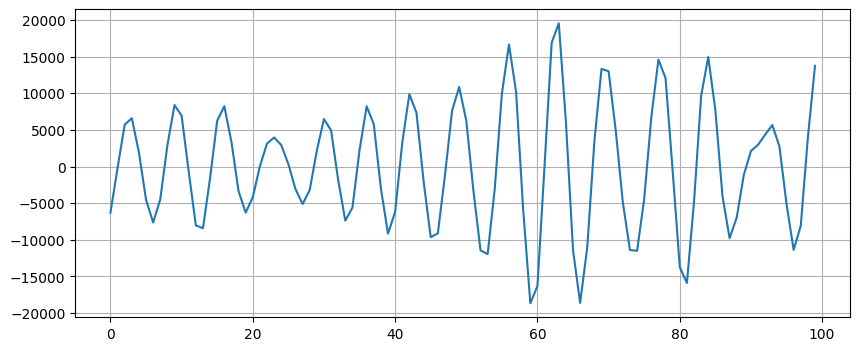

In [16]:
plt.plot(initial_samples_matrix[0,-100:])
plt.show()

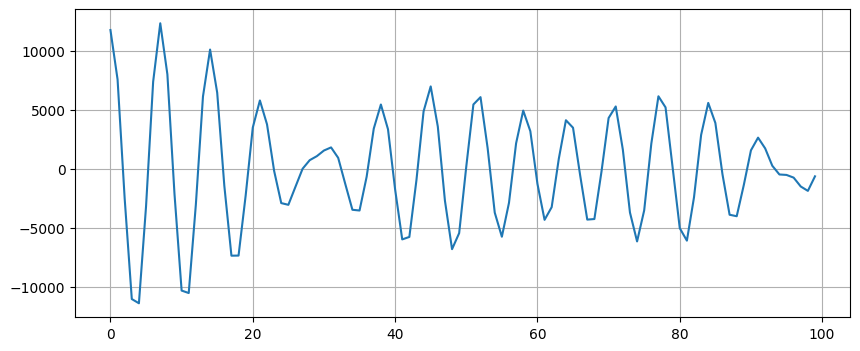

In [17]:
plt.plot(dynamic_samples_matrix[0,:100])
plt.show()

In [67]:
dynamic_samples_matrix

array([[11755,  7577, -2514, ...,  5240, 10945,  8835],
       [    0,     0,     0, ...,     0,     0,     0]],
      shape=(2, 6250016), dtype=int16)

In [68]:
6250016/625

10000.0256

In [24]:
a = np.array([1,2,3])
a = a[:,None]

b = np.array([1,2,3])

a * b[None,:]

array([[1, 2, 3],
       [2, 4, 6],
       [3, 6, 9]])

In [42]:
a = {1:111,2:222}
b = {2:111,1:333}
c = a.copy()
a.keys() == b.keys()

True

In [41]:
c[2] = 333
a

{1: 111, 2: 222}